In [2]:
import pandas as pd
print("Pandas version:", pd.__version__)

Pandas version: 3.0.3


In [1]:
import sys
print(sys.executable)

c:\Users\rbhat\AppData\Local\Programs\Python\Python314\python.exe


In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 5.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/9.9 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.9 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 4.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.5 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 4.3 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 4.4 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 4.4 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load and Inspect Data

In [7]:
import pandas as pd
import numpy as np

file_path = r'C:\Users\rbhat\Downloads\Amazon Sale Report.csv'

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Amount', 'Category'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

Shape: (128976, 19)
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel ship-service-level  Category Size Courier Status  \
0   Merchant     Amazon.in           Standard   T-shirt    S     On the Way   
1   Merchant     Amazon.in           Standard     Shirt  3XL        Shipped   
2     Amazon     Amazon.in          Expedited     Shirt   XL        Shipped   
3   Merchant     Amazon.in           Standard   Blazzer    L     On the Way   
4     Amazon     Amazon.in          Expedited  Trousers  3XL        Shipped   

   Qty currency  Amount    ship-city   ship-state  ship-postal-cod

C:\Users\rbhat\AppData\Local\Temp\ipykernel_26580\4265985067.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


Amount Distribution

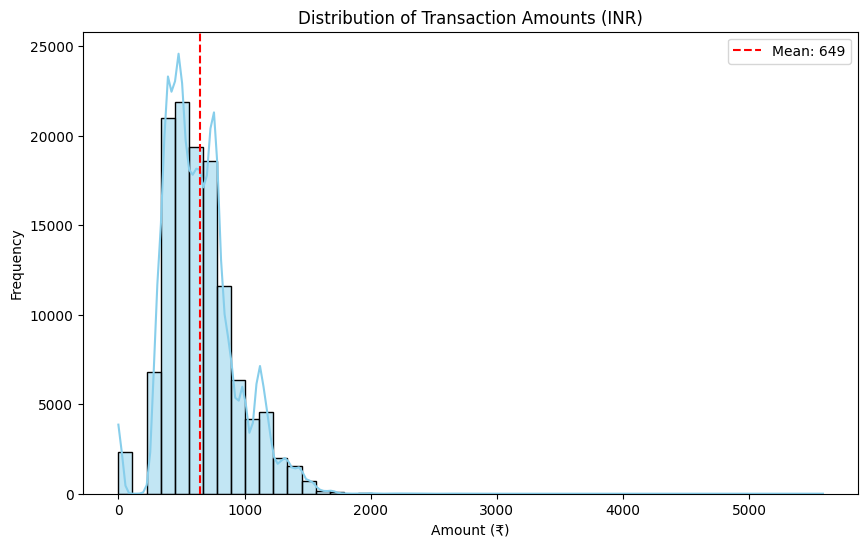

Amount Statistics:
 count    121176.000000
mean        648.562176
std         281.185041
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64


In [10]:

plt.figure(figsize=(10, 6)) 
sns.histplot(df['Amount'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts (INR)')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')
plt.axvline(df['Amount'].mean(), color='red', linestyle='--', label=f'Mean: {df["Amount"].mean():.0f}')
plt.legend()
plt.show()
# Insight: Right-skewed, majority between ₹500–₹1000
print("Amount Statistics:\n", df['Amount'].describe())

Amount Outliners

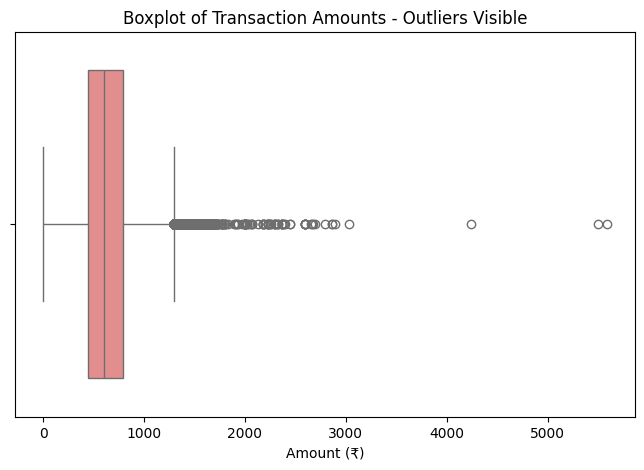

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Amount'], color='lightcoral')
plt.title('Boxplot of Transaction Amounts - Outliers Visible')
plt.xlabel('Amount (₹)')
plt.show()

Amount by Product Category

C:\Users\rbhat\AppData\Local\Temp\ipykernel_26580\2065271393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Amount', y='Category', data=df, order=order, palette='viridis')


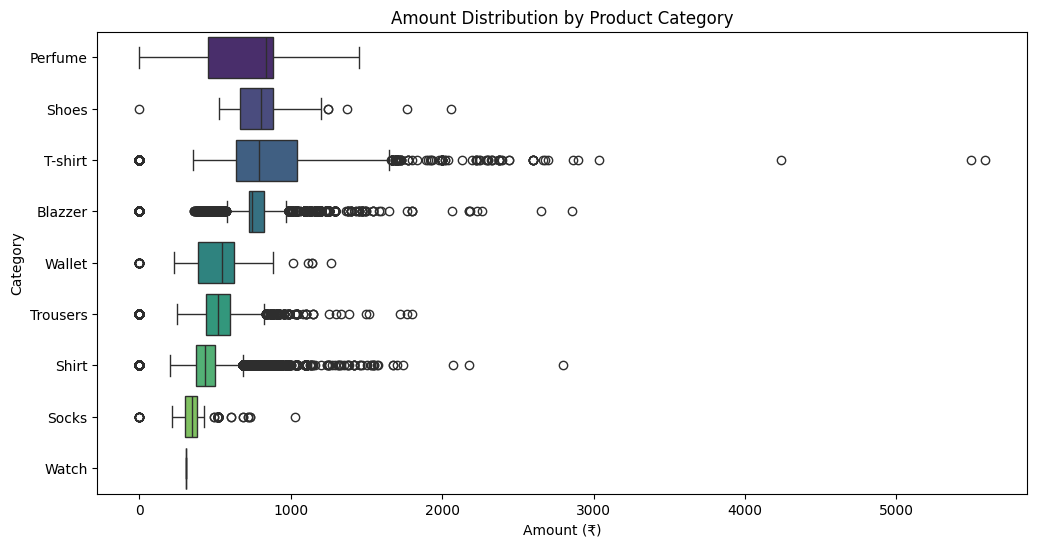

In [12]:
plt.figure(figsize=(12, 6))
order = df.groupby('Category')['Amount'].median().sort_values(ascending=False).index
sns.boxplot(x='Amount', y='Category', data=df, order=order, palette='viridis')
plt.title('Amount Distribution by Product Category')
plt.xlabel('Amount (₹)')
plt.ylabel('Category')
plt.show()

Top Product Category by Frequency

C:\Users\rbhat\AppData\Local\Temp\ipykernel_26580\1473559125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_d')


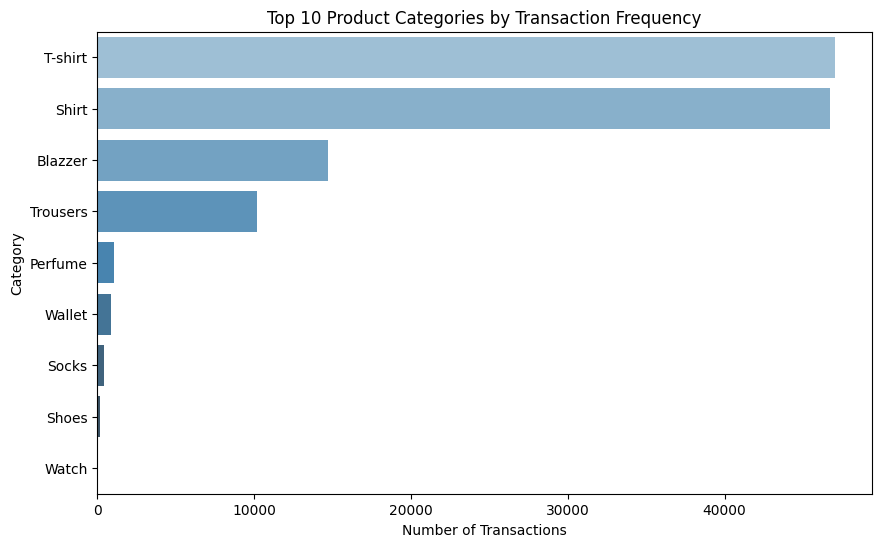

Top Categories:
 Category
T-shirt     47049
Shirt       46713
Blazzer     14703
Trousers    10160
Perfume      1091
Wallet        881
Socks         420
Shoes         156
Watch           3
Name: count, dtype: int64


In [13]:
category_counts = df['Category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_d')
plt.title('Top 10 Product Categories by Transaction Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Category')
plt.show()

print("Top Categories:\n", category_counts)